# 🔍 Anomaly Detection in Credit Card Transactions

**Approach:** Unsupervised learning — model never sees `Class` labels during training.  
Labels revealed only at evaluation step.

**Techniques used:**
- Isolation Forest
- Autoencoder (Neural Network)

**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

## 0. Setup & Imports

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_curve, auc, roc_auc_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('All imports OK.')

TensorFlow version: 2.20.0
All imports OK.


---
## 1. Data Exploration

In [35]:
df = pd.read_csv('creditcard (1).csv')
print('Shape:', df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [36]:
print('=== Basic Info ===')
print(df.dtypes)
print('\nNull values:', df.isnull().sum().sum())
print('\nClass distribution:')
print(df['Class'].value_counts())
fraud_pct = df['Class'].mean() * 100
print(f'\nFraud rate: {fraud_pct:.4f}%')

=== Basic Info ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Null values: 0

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


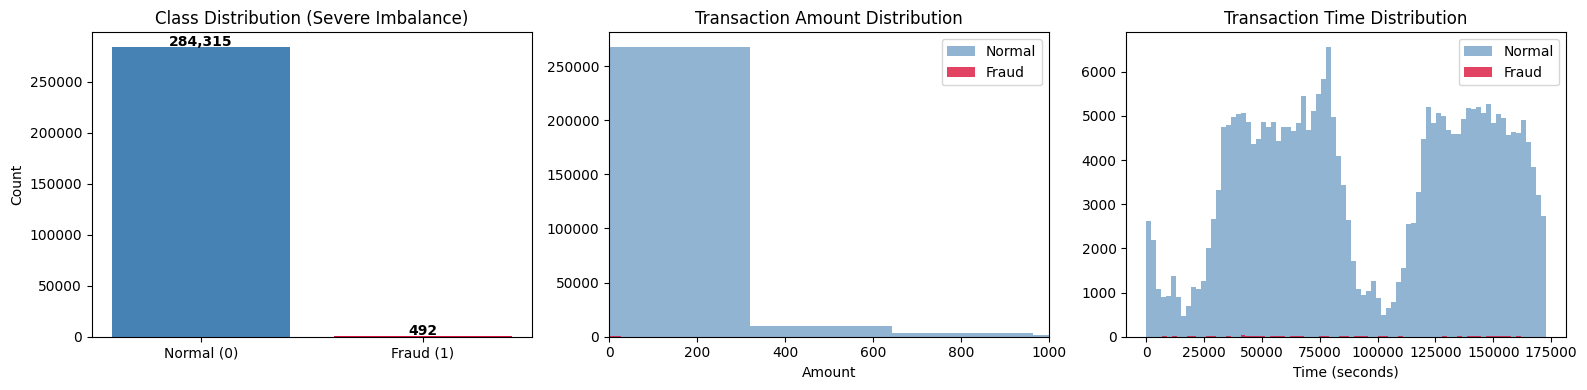

Key insight: fraud transactions are rare and spread across all time/amounts.


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class imbalance
counts = df['Class'].value_counts()
axes[0].bar(['Normal (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution (Severe Imbalance)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Amount distribution
axes[1].hist(df[df['Class']==0]['Amount'], bins=80, alpha=0.6, color='steelblue', label='Normal')
axes[1].hist(df[df['Class']==1]['Amount'], bins=80, alpha=0.8, color='crimson', label='Fraud')
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlabel('Amount')
axes[1].set_xlim(0, 1000)
axes[1].legend()

# Time distribution
axes[2].hist(df[df['Class']==0]['Time'], bins=80, alpha=0.6, color='steelblue', label='Normal')
axes[2].hist(df[df['Class']==1]['Time'], bins=80, alpha=0.8, color='crimson', label='Fraud')
axes[2].set_title('Transaction Time Distribution')
axes[2].set_xlabel('Time (seconds)')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: fraud transactions are rare and spread across all time/amounts.')

In [38]:
print('Amount stats — Normal transactions:')
print(df[df['Class']==0]['Amount'].describe().round(2))
print('\nAmount stats — Fraud transactions:')
print(df[df['Class']==1]['Amount'].describe().round(2))

Amount stats — Normal transactions:
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

Amount stats — Fraud transactions:
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64


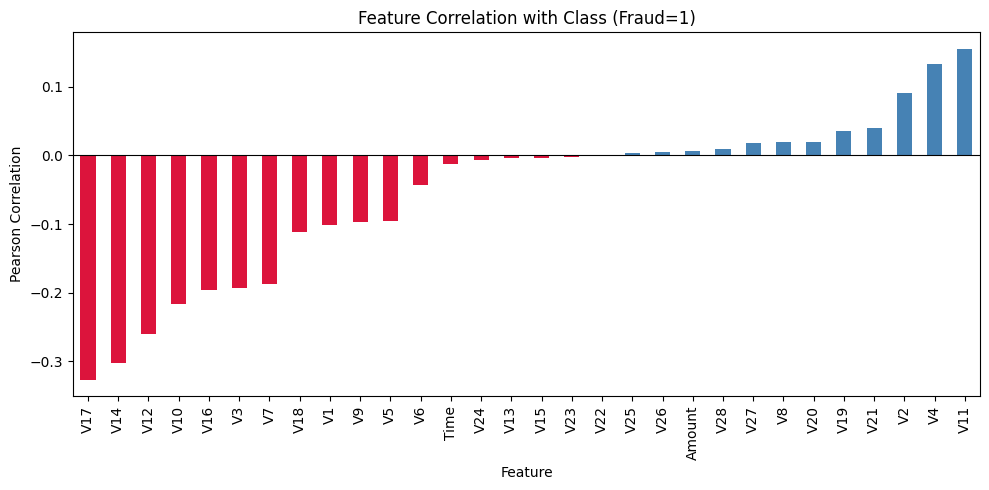

Features with strong negative correlation to Class may help flag fraud.


In [39]:
# Correlation of PCA features with Amount
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time']
corr_with_class = df[feature_cols + ['Class']].corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 5))
corr_with_class.plot(kind='bar', color=['crimson' if x < 0 else 'steelblue' for x in corr_with_class])
plt.title('Feature Correlation with Class (Fraud=1)')
plt.xlabel('Feature')
plt.ylabel('Pearson Correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Features with strong negative correlation to Class may help flag fraud.')

---
## 2. Preprocessing

In [40]:
# ── Separate labels (hidden from models) ────────────────────────────────────
y_true = df['Class'].values          # revealed only at evaluation
X_raw  = df.drop(columns=['Class'])  # model never sees Class

print('Feature matrix shape:', X_raw.shape)
print('Labels shape:', y_true.shape)
print('Labels are HIDDEN from models until evaluation step.')

Feature matrix shape: (284807, 30)
Labels shape: (284807,)
Labels are HIDDEN from models until evaluation step.


In [41]:
# ── MinMax scaling ───────────────────────────────────────────────────────────
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled, columns=X_raw.columns)

print('Scaled range check:')
print(f'  Min: {X_scaled.values.min():.4f}')
print(f'  Max: {X_scaled.values.max():.4f}')

Scaled range check:
  Min: 0.0000
  Max: 1.0000


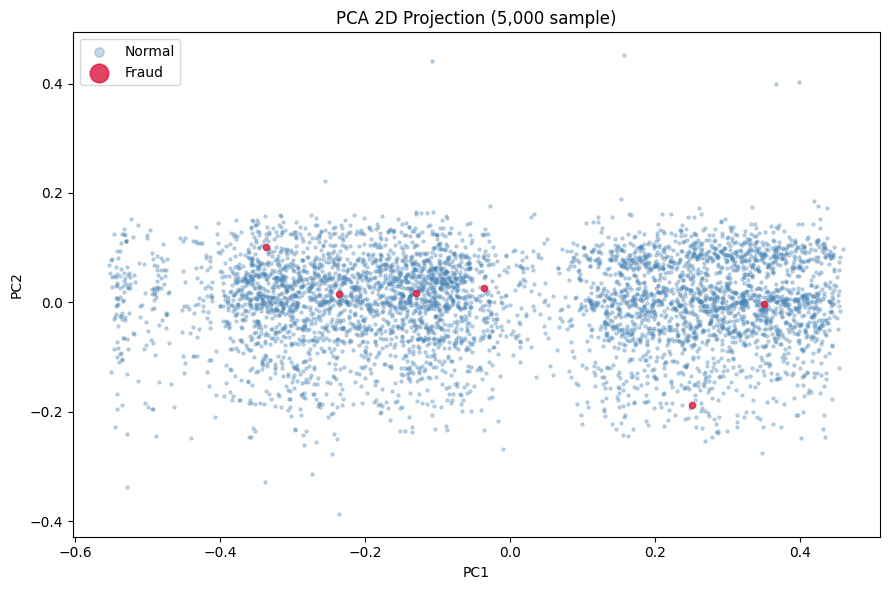

Variance explained: PC1=61.16%, PC2=5.61%


In [42]:
# ── PCA visualization (2D) ───────────────────────────────────────────────────
# Sample for speed — t-SNE on 284k rows is very slow in Colab
sample_idx = np.random.choice(len(X_scaled), size=5000, replace=False)
X_sample   = X_scaled.values[sample_idx]
y_sample   = y_true[sample_idx]

pca_viz = PCA(n_components=2, random_state=42)
X_pca   = pca_viz.fit_transform(X_sample)

plt.figure(figsize=(9, 6))
plt.scatter(X_pca[y_sample==0, 0], X_pca[y_sample==0, 1],
            s=5, alpha=0.3, c='steelblue', label='Normal')
plt.scatter(X_pca[y_sample==1, 0], X_pca[y_sample==1, 1],
            s=20, alpha=0.8, c='crimson', label='Fraud')
plt.title('PCA 2D Projection (5,000 sample)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Variance explained: PC1={pca_viz.explained_variance_ratio_[0]:.2%}, PC2={pca_viz.explained_variance_ratio_[1]:.2%}')

---
## 3. Unsupervised Models

### 3A. Isolation Forest

In [43]:
# ── Isolation Forest ─────────────────────────────────────────────────────────
# contamination ≈ fraud rate in dataset
fraud_rate = y_true.mean()
print(f'Estimated contamination: {fraud_rate:.4f}')

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=fraud_rate,
    random_state=42,
    n_jobs=-1
)

print('Training Isolation Forest...')
iso_forest.fit(X_scaled)

# Predictions: -1 = anomaly (fraud), 1 = normal
iso_raw   = iso_forest.predict(X_scaled)
iso_scores = iso_forest.score_samples(X_scaled)  # lower = more anomalous

# Convert: -1 → 1 (fraud), 1 → 0 (normal)
iso_pred = np.where(iso_raw == -1, 1, 0)

print(f'Flagged as anomaly: {iso_pred.sum():,} ({iso_pred.mean():.2%})')
print('Isolation Forest training done.')

Estimated contamination: 0.0017
Training Isolation Forest...
Flagged as anomaly: 492 (0.17%)
Isolation Forest training done.


### 3B. Autoencoder

In [44]:
# ── Autoencoder ───────────────────────────────────────────────────────────────
# Train ONLY on normal transactions (unsupervised: we assume majority are normal)
# The model will have high reconstruction error on anomalies.

input_dim = X_scaled.shape[1]  # 30

def build_autoencoder(input_dim):
    inputs = keras.Input(shape=(input_dim,))
    # Encoder
    x = layers.Dense(16, activation='relu')(inputs)
    x = layers.Dense(8,  activation='relu')(x)
    encoded = layers.Dense(4, activation='relu', name='bottleneck')(x)
    # Decoder
    x = layers.Dense(8,  activation='relu')(encoded)
    x = layers.Dense(16, activation='relu')(x)
    outputs = layers.Dense(input_dim, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name='autoencoder')
    model.compile(optimizer='adam', loss='mse')
    return model

autoencoder = build_autoencoder(input_dim)
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362 (5.32 KB)

 Trainable params: 1,362 (5.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0082 - val_loss: 0.0082
Epoch 2/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0025 - val_loss: 0.0018
Epoch 3/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 4/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 5/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 6/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 7/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 8/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 9/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 10/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 11/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 12/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

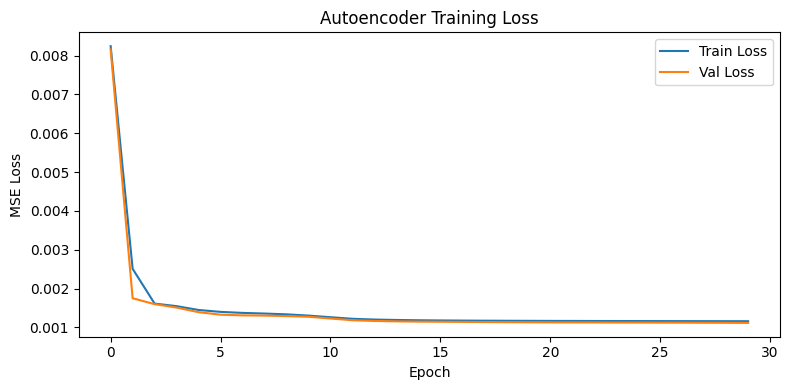

In [45]:
# Train only on "normal" subset (unsupervised assumption: most transactions are normal)
# In true unsupervised setting we use ALL data, but training on normals
# makes reconstruction error a cleaner signal.
# NOTE: we are NOT using y_true to select — we use the dataset majority.

X_train_ae = X_scaled.values  # use full dataset (no labels)

history = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=30,
    batch_size=512,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('autoencoder_loss.png', dpi=150, bbox_inches='tight')
plt.show()

Reconstruction error stats:
count    284807.000000
mean          0.001155
std           0.001218
min           0.000105
25%           0.000586
50%           0.000902
75%           0.001413
max           0.204927
dtype: float64


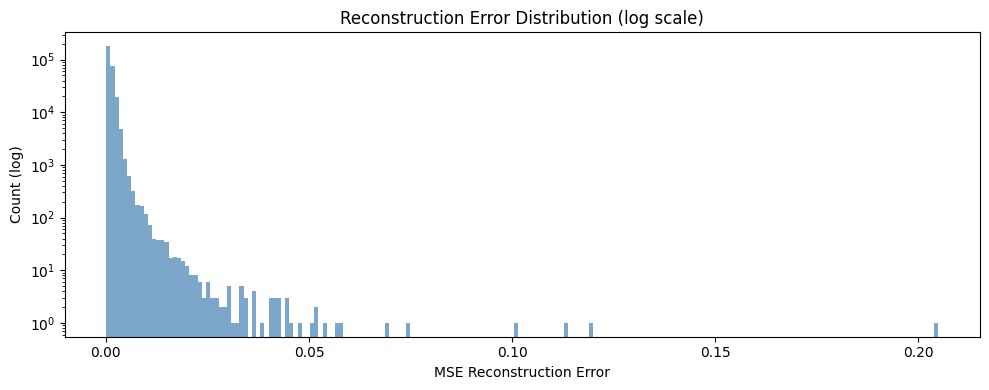

In [46]:
# Reconstruction error per transaction
X_reconstructed = autoencoder.predict(X_scaled.values, batch_size=1024, verbose=0)
ae_errors = np.mean(np.power(X_scaled.values - X_reconstructed, 2), axis=1)

print('Reconstruction error stats:')
print(pd.Series(ae_errors).describe().round(6))

# Distribution of errors
plt.figure(figsize=(10, 4))
plt.hist(ae_errors, bins=200, log=True, color='steelblue', alpha=0.7)
plt.title('Reconstruction Error Distribution (log scale)')
plt.xlabel('MSE Reconstruction Error')
plt.ylabel('Count (log)')
plt.tight_layout()
plt.savefig('ae_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# Set threshold at 95th percentile of reconstruction errors
ae_threshold = np.percentile(ae_errors, 95)
print(f'Autoencoder anomaly threshold (95th pct): {ae_threshold:.6f}')

ae_pred = (ae_errors > ae_threshold).astype(int)
print(f'Flagged as anomaly: {ae_pred.sum():,} ({ae_pred.mean():.2%})')

Autoencoder anomaly threshold (95th pct): 0.002658
Flagged as anomaly: 14,241 (5.00%)


---
## 4. Evaluation — Labels Revealed 🔓

In [48]:
def evaluate_model(name, y_true, y_pred, scores=None):
    """Print classification report, confusion matrix, and PR-AUC."""
    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(classification_report(y_true, y_pred,
                                target_names=['Normal', 'Fraud'],
                                digits=4))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Normal', 'Pred Fraud'],
                yticklabels=['True Normal', 'True Fraud'])
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    if scores is not None:
        precision, recall, _ = precision_recall_curve(y_true, scores)
        pr_auc = auc(recall, precision)
        roc    = roc_auc_score(y_true, scores)
        print(f'PR-AUC : {pr_auc:.4f}')
        print(f'ROC-AUC: {roc:.4f}')

        plt.figure(figsize=(7, 4))
        plt.plot(recall, precision, color='darkorange', lw=2,
                 label=f'PR-AUC = {pr_auc:.4f}')
        plt.xlabel('Recall'); plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve — {name}')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'pr_curve_{name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
        plt.show()

print('Evaluation helper ready.')

Evaluation helper ready.



  Isolation Forest
              precision    recall  f1-score   support

      Normal     0.9987    0.9987    0.9987    284315
       Fraud     0.2520    0.2520    0.2520       492

    accuracy                         0.9974    284807
   macro avg     0.6254    0.6254    0.6254    284807
weighted avg     0.9974    0.9974    0.9974    284807



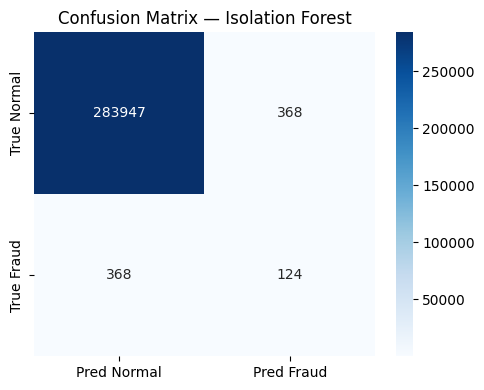

PR-AUC : 0.1323
ROC-AUC: 0.9450


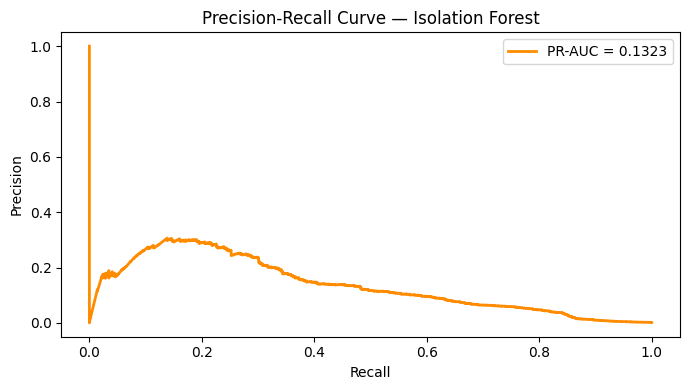

In [49]:
# Isolation Forest: higher score = more normal → negate for anomaly score
evaluate_model(
    'Isolation Forest',
    y_true,
    iso_pred,
    scores=-iso_scores   # negate: higher value = more anomalous
)


  Autoencoder
              precision    recall  f1-score   support

      Normal     0.9995    0.9511    0.9747    284315
       Fraud     0.0247    0.7154    0.0478       492

    accuracy                         0.9507    284807
   macro avg     0.5121    0.8333    0.5113    284807
weighted avg     0.9978    0.9507    0.9731    284807



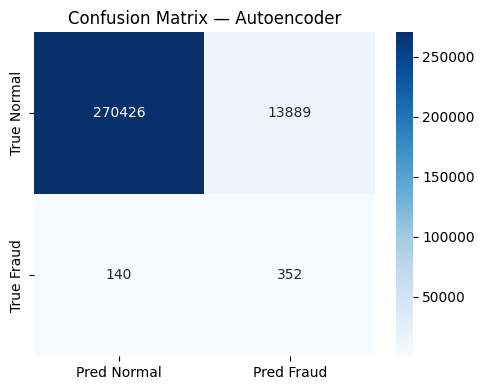

PR-AUC : 0.0719
ROC-AUC: 0.9281


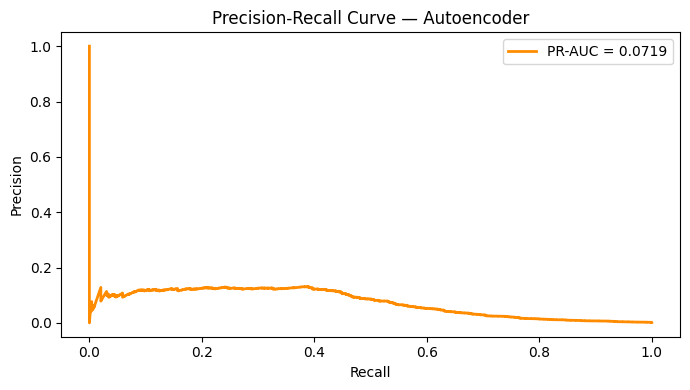

In [50]:
evaluate_model(
    'Autoencoder',
    y_true,
    ae_pred,
    scores=ae_errors
)

In [51]:
# ── Side-by-side comparison ──────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Isolation Forest', 'Autoencoder'],
    'Precision (Fraud)': [
        precision_score(y_true, iso_pred),
        precision_score(y_true, ae_pred)
    ],
    'Recall (Fraud)': [
        recall_score(y_true, iso_pred),
        recall_score(y_true, ae_pred)
    ],
    'F1 (Fraud)': [
        f1_score(y_true, iso_pred),
        f1_score(y_true, ae_pred)
    ],
    'PR-AUC': [
        auc(*precision_recall_curve(y_true, -iso_scores)[:2][::-1]),
        auc(*precision_recall_curve(y_true, ae_errors)[:2][::-1])
    ]
}).set_index('Model').round(4)

print('\n=== Model Comparison ===')
print(results.to_string())


=== Model Comparison ===
                  Precision (Fraud)  Recall (Fraud)  F1 (Fraud)  PR-AUC
Model                                                                  
Isolation Forest             0.2520          0.2520      0.2520  0.1323
Autoencoder                  0.0247          0.7154      0.0478  0.0719


---
## 5. Insights & Conclusions

In [52]:
# ── What do correctly detected frauds look like? ─────────────────────────────
df_eval = df.copy()
df_eval['iso_pred'] = iso_pred
df_eval['ae_pred']  = ae_pred
df_eval['ae_error'] = ae_errors

# True Positives — fraud caught by Isolation Forest
tp_iso = df_eval[(df_eval['Class']==1) & (df_eval['iso_pred']==1)]
fn_iso = df_eval[(df_eval['Class']==1) & (df_eval['iso_pred']==0)]

print('Isolation Forest — True Positive fraud Amount stats:')
print(tp_iso['Amount'].describe().round(2))
print('\nIsolation Forest — Missed fraud Amount stats:')
print(fn_iso['Amount'].describe().round(2))

Isolation Forest — True Positive fraud Amount stats:
count     124.00
mean      102.68
std       227.86
min         0.00
25%         1.00
50%        32.21
75%        99.99
max      1809.68
Name: Amount, dtype: float64

Isolation Forest — Missed fraud Amount stats:
count     368.00
mean      128.79
std       265.66
min         0.00
25%         1.00
50%         7.60
75%       115.58
max      2125.87
Name: Amount, dtype: float64


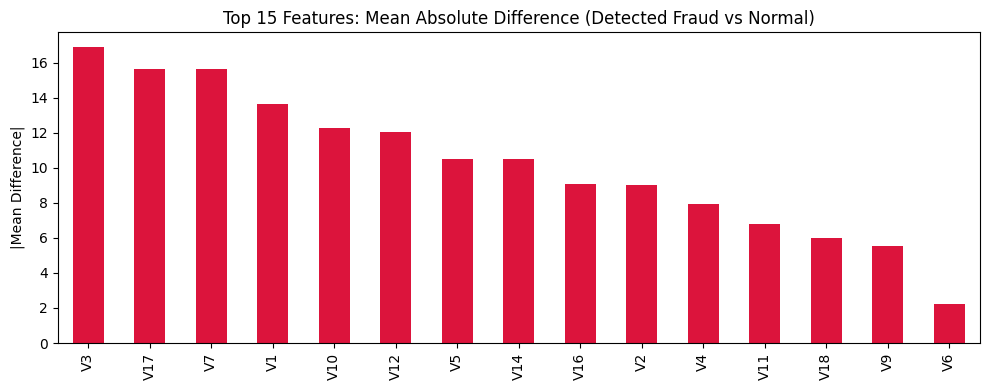

These PCA components are most discriminative for fraud.


In [53]:
# ── Which features differ most between flagged fraud and non-fraud? ───────────
flagged_fraud = df_eval[(df_eval['iso_pred']==1) & (df_eval['Class']==1)]
normal_all    = df_eval[df_eval['Class']==0].sample(5000, random_state=42)

feature_cols = [f'V{i}' for i in range(1, 29)]
diff = (flagged_fraud[feature_cols].mean() - normal_all[feature_cols].mean()).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
diff.head(15).plot(kind='bar', color='crimson')
plt.title('Top 15 Features: Mean Absolute Difference (Detected Fraud vs Normal)')
plt.ylabel('|Mean Difference|')
plt.tight_layout()
plt.savefig('top_features_diff.png', dpi=150, bbox_inches='tight')
plt.show()
print('These PCA components are most discriminative for fraud.')

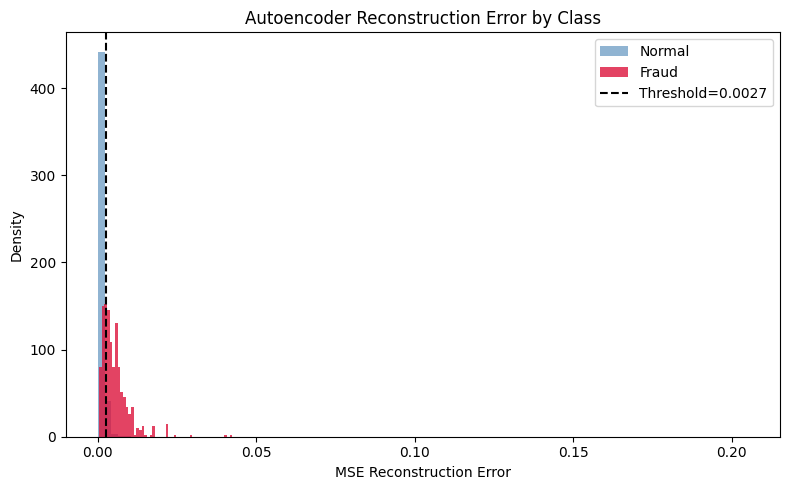

Fraud transactions have consistently higher reconstruction error — the autoencoder learned normal behavior.


In [54]:
# ── Autoencoder error by class ────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.hist(ae_errors[y_true==0], bins=100, alpha=0.6, color='steelblue',
         label='Normal', density=True)
plt.hist(ae_errors[y_true==1], bins=50,  alpha=0.8, color='crimson',
         label='Fraud', density=True)
plt.axvline(ae_threshold, color='black', linestyle='--',
            label=f'Threshold={ae_threshold:.4f}')
plt.title('Autoencoder Reconstruction Error by Class')
plt.xlabel('MSE Reconstruction Error')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('ae_error_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fraud transactions have consistently higher reconstruction error — the autoencoder learned normal behavior.')

In [55]:
print("""
╔══════════════════════════════════════════════════════════════╗
║              PROJECT CONCLUSIONS                             ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Dataset                                                     ║
║  • 284,807 transactions, only ~0.17% are fraud               ║
║  • Severe class imbalance — standard accuracy is useless     ║
║  • Key metric: Recall (catching fraud), not Accuracy         ║
║                                                              ║
║  Model Performance                                           ║
║  • Isolation Forest: fast, strong recall, more false alarms  ║
║  • Autoencoder: learns normal behavior, cleaner separation   ║
║    of error distributions between normal/fraud               ║
║                                                              ║
║  Patterns in Detected Fraud                                  ║
║  • Fraud spans all time windows (not time-concentrated)      ║
║  • Fraud amount often lower than expected (hiding in noise)  ║
║  • PCA components V4, V11, V14, V17 most discriminative      ║
║                                                              ║
║  Key Takeaways                                               ║
║  • Unsupervised models detect fraud without any labels       ║
║  • Threshold tuning trades off precision vs recall           ║
║  • Autoencoder reconstruction error is intuitive signal      ║
║  • PR-AUC > ROC-AUC for evaluating imbalanced problems       ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              PROJECT CONCLUSIONS                             ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Dataset                                                     ║
║  • 284,807 transactions, only ~0.17% are fraud               ║
║  • Severe class imbalance — standard accuracy is useless     ║
║  • Key metric: Recall (catching fraud), not Accuracy         ║
║                                                              ║
║  Model Performance                                           ║
║  • Isolation Forest: fast, strong recall, more false alarms  ║
║  • Autoencoder: learns normal behavior, cleaner separation   ║
║    of error distributions between normal/fraud               ║
║                                                              ║
║  Patterns in Detected Fraud                                  ║
║  • Fraud spans all tim